<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/15_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p><img alt="numpy logo" height="150px" src="https://seaborn.pydata.org/_images/logo-wide-lightbg.svg" align="left" hspace="10px" vspace="0px"></p>

https://seaborn.pydata.org/

<h1> Física computacional 1</h1>
Prof: Andrés F. Rivera R.

<h1> seaborn: statistical data visualization</h1>

**Michaesl L. Waskom** A paper describing seaborn has been published in the Journal of Open Source Software:
https://joss.theoj.org/papers/10.21105/joss.03021


seaborn is a library for making statistical graphics in Python. It provides a high-level interface
to matplotlib and integrates closely with pandas data structures....

In [20]:
# Import numpy and pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# Example fMRI: (using pandas and matplotlib)

La resonancia magnética funcional (fMRI) es una técnica de diagnóstico no invasiva que mapea la actividad cerebral midiendo cambios en el flujo sanguíneo y la oxigenación (efecto BOLD), a diferencia de la RM convencional que solo muestra estructura. Se usa para identificar áreas cerebrales críticas funcionales (habla, motoras) antes de cirugías.


In [33]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/fmri.csv'
fmri = pd.read_csv(url)
fmri[:5]

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [25]:
fmri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subject    1064 non-null   object 
 1   timepoint  1064 non-null   int64  
 2   event      1064 non-null   object 
 3   region     1064 non-null   object 
 4   signal     1064 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 41.7+ KB


In [26]:
fmri.columns

Index(['subject', 'timepoint', 'event', 'region', 'signal'], dtype='object')

**Dataset Details** (IA)

The dataset is long-form and contains measurements of brain activity (signal) across different subjects, timepoints, events, and regions. It includes:
* **subject**: An identifier for each participant in the study.
* **timepoint**: The time point at which the measurement was taken.
* **event**: The type of event (e.g., 'stim' for stimulation or 'rest' for rest).
* **region**: The brain region being observed (e.g., 'parietal' or 'frontal').
* **signal**: The measured fMRI signal intensity (blood-oxygen-level-dependent or BOLD signal).

**Origin**

The original data is derived from a neuroimaging study and was adapted for use in Seaborn's documentation and examples. It is particularly useful for demonstrating time-series plots and statistical aggregation capabilities in Seaborn.

**Common Usage in Seaborn**

The fmri dataset is especially useful for demonstrating how Seaborn automatically aggregates repeated measures (like multiple signal readings for the same timepoint, event, and region) to produce informative plots with confidence intervals. A typical use case is creating a line plot to visualize the change in signal over time across different regions or events:

In [34]:
fmri

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970
...,...,...,...,...,...
1059,s0,8,cue,frontal,0.018165
1060,s13,7,cue,frontal,-0.029130
1061,s12,7,cue,frontal,-0.004939
1062,s11,7,cue,frontal,-0.025367


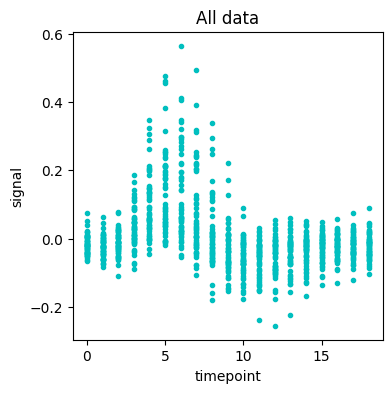

In [35]:
plt.figure(figsize=(4,4))
plt.plot(fmri["timepoint"], fmri["signal"],'c.')
plt.xlabel("timepoint")
plt.ylabel("signal")
plt.title('All data')
#plt.grid()
plt.show()

In [43]:
kk = fmri[np.logical_and(fmri.event == 'stim', fmri.region == 'parietal')]

kk.reset_index()
del kk['index']

,index,subject,timepoint,event,region,signal
0,0,s13,18,stim,parietal,-0.017552
1,1,s5,14,stim,parietal,-0.080883
2,2,s12,18,stim,parietal,-0.081033
3,3,s11,18,stim,parietal,-0.046134
4,4,s10,18,stim,parietal,-0.037970
...,...,...,...,...,...,...
261,263,s2,0,stim,parietal,-0.034407
262,264,s5,9,stim,parietal,-0.074843
263,265,s0,13,stim,parietal,-0.055264
264,266,s6,16,stim,parietal,-0.039951


In [45]:
kk

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970
...,...,...,...,...,...
263,s2,0,stim,parietal,-0.034407
264,s5,9,stim,parietal,-0.074843
265,s0,13,stim,parietal,-0.055264
266,s6,16,stim,parietal,-0.039951


In [37]:
fmri[fmri.region == 'parietal']

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970
...,...,...,...,...,...
930,s7,16,cue,parietal,-0.024589
931,s8,9,cue,parietal,-0.039664
949,s6,9,cue,parietal,-0.069248
967,s5,9,cue,parietal,-0.056757


In [46]:
#Cut in the DataFrame
parstim = fmri[np.logical_and(fmri.event == 'stim', fmri.region == 'parietal')]
parstim = parstim.reset_index()
del parstim['index']
parcue = fmri[np.logical_and(fmri.event == 'cue', fmri.region == 'parietal')]
parcue = parcue.reset_index()
del parcue['index']

fronstim = fmri[np.logical_and(fmri.event == 'stim', fmri.region == 'frontal')]
fronstim = fronstim.reset_index()
del fronstim['index']
froncue = fmri[np.logical_and(fmri.event == 'cue', fmri.region == 'frontal')]
froncue = froncue.reset_index()
del froncue['index']

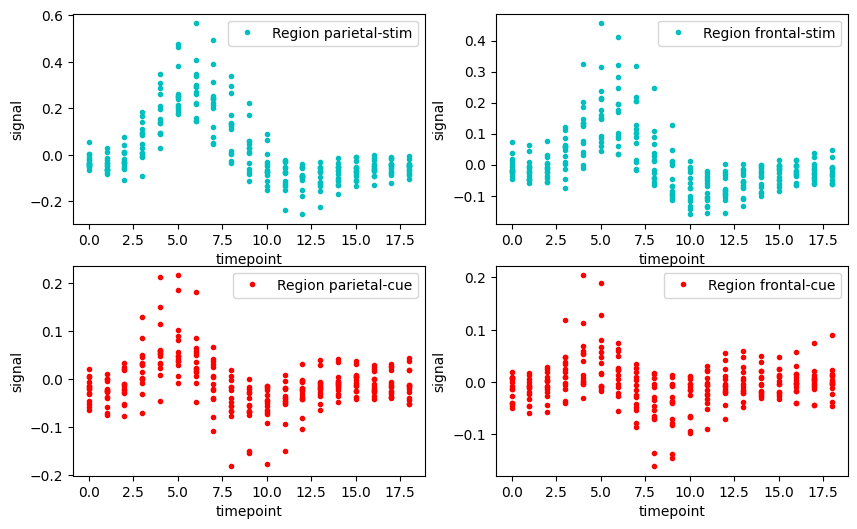

In [49]:
# Create a figure and a 2x2 grid of axes
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

#PARIETAL STIM
ax[0,0].plot(parstim["timepoint"], parstim["signal"],'c.')
ax[0,0].set_xlabel("timepoint")
ax[0,0].set_ylabel("signal")
ax[0,0].legend(['Region parietal-stim'])
#PARIETAL CUE
ax[1,0].plot(parcue["timepoint"], parcue["signal"],'r.')
ax[1,0].set_xlabel("timepoint")
ax[1,0].set_ylabel("signal")
ax[1,0].legend(['Region parietal-cue'])

#FRONTAL STIM
ax[0,1].plot(fronstim["timepoint"], fronstim["signal"],'c.')
ax[0,1].set_xlabel("timepoint")
ax[0,1].set_ylabel("signal")
ax[0,1].legend(['Region frontal-stim'])
#FRONTAL CUE
ax[1,1].plot(froncue["timepoint"], froncue["signal"],'r.')
ax[1,1].set_xlabel("timepoint")
ax[1,1].set_ylabel("signal")
ax[1,1].legend(['Region frontal-cue'])

plt.show()

In [50]:
len(parstim)

266

[-0.0012938   0.02054071 -0.01550556] 7.164290766925498e-07


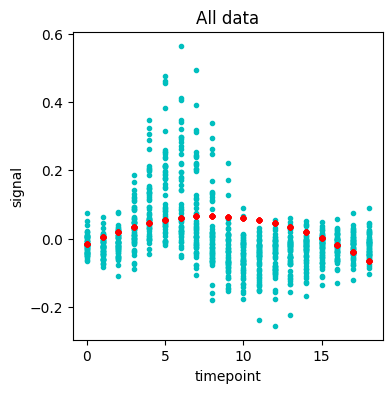

In [51]:
#Do the fit...
from scipy.optimize import curve_fit

def curve_function(x, a, b, c):
    return a*x + b*np.cos(x) + c*np.sin(x)

# perform our curve fit
parameter, covariance = curve_fit(curve_function, parstim.timepoint, parstim.signal)
print(parameter,covariance[0][0])

plt.figure(figsize=(4,4))
plt.plot(fmri["timepoint"], fmri["signal"],'c.')
plt.plot(parstim.timepoint, np.polyval(parameter, parstim.timepoint),'r.')
plt.xlabel("timepoint")
plt.ylabel("signal")
plt.title('All data')
plt.show()

Homework

In [52]:
#Mean value in each bin: function
signal_j = []
signal_k = []

for j in range(parstim.timepoint.min(),parstim.timepoint.max()+1):
  s = 0
  n = 0
  for i in range(0,len(parstim)):
    if parstim.timepoint[i] == j:

      s += parstim.signal[i]
      n += 1
  signal_j.append(s/n)

signal_k = []

for j in range(parcue.timepoint.min(),parcue.timepoint.max()+1):
  s = 0
  n = 0
  for i in range(0,len(parstim)):
    if parcue.timepoint[i] == j:

      s += parcue.signal[i]
      n += 1
  signal_k.append(s/n)

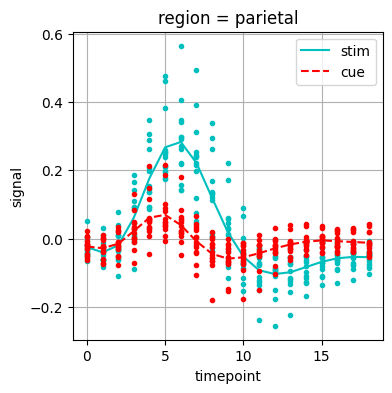

In [55]:
plt.figure(figsize=(4,4))
plt.plot(signal_j,'c-',label='stim')
plt.plot(parstim.timepoint,parstim.signal, 'c.')
plt.plot(parcue.timepoint,parcue.signal, 'r.')
plt.plot(signal_k,'r--',label='cue')
plt.grid()
plt.xlabel("timepoint")
plt.ylabel("signal")
plt.title('region = parietal')
plt.legend()
plt.show()

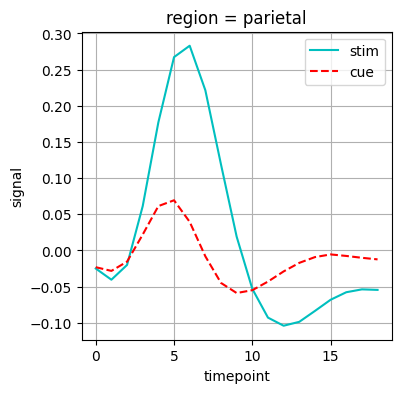

In [56]:
plt.figure(figsize=(4,4))
plt.plot(signal_j,'c-',label='stim')
plt.plot(signal_k,'r--',label='cue')
plt.grid()
plt.xlabel("timepoint")
plt.ylabel("signal")
plt.title('region = parietal')
plt.legend()
plt.show()

## Example:
The following example demonstrates the creation of a figure with seaborn. The example makes use of one of the built-in datasets that are provided for documentation and generation of reproducible bug reports. It illustrates several of the features described in the Overview section,
including the declarative API, semantic mappings, faceting across subplots, aggregation with error bars, and visual theme control.

Using directly seaborn:

In [57]:
#using usual technics: Matplotlib
#Import data
fmri = sns.load_dataset("fmri")
#diplay
fmri[:2]

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883


In [58]:
fmri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subject    1064 non-null   object 
 1   timepoint  1064 non-null   int64  
 2   event      1064 non-null   object 
 3   region     1064 non-null   object 
 4   signal     1064 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 41.7+ KB


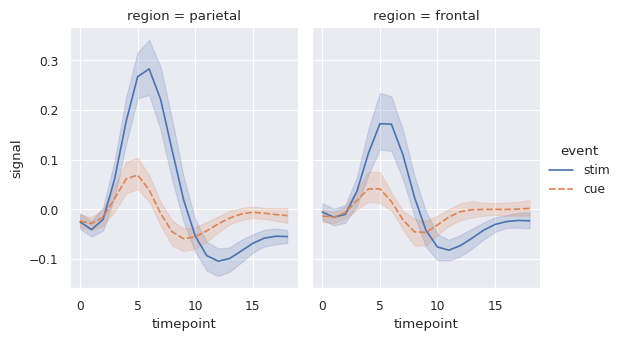

In [59]:
#import seaborn as sns

sns.set_theme(context="paper")
fmri = sns.load_dataset("fmri")
g = sns.relplot(
data=fmri, kind="line",
x="timepoint", y="signal",
hue="event", style="event", col="region",
height=3.5, aspect=.8,)
g.savefig("paper_demo.pdf")

* Functions in seaborn are classified as either “axes-level” or
“figure-level.”
1.  Axes-level functions behave like most plotting functions in the matplotlib.
2. Figure-level functions create their own figure when invoked, allowing them to “facet” the dataset by creating multiple conditional subplots, along with adding conveniences such as putting
the legend outside the space of the plot by default.

# TUTORIAL BÁSICO:

1. Gráficos básicos (en Ciencia de Datos)
2. Personalización de gráficos

## 1. Gráficos básicos

Veamos lo sencillo que resulta generar varios tipos de gráficos de uso común al realizar Análisis Exploratorio de Datos en Python.

Comencemos leyendo los sets de datos:

In [60]:
ls sample_data/

anscombe.json*                millas_por_galon.csv
apple_stock.csv               mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


In [61]:
df_apple = pd.read_csv('sample_data/apple_stock.csv', parse_dates=['ds'])
#df_mpg = pd.read_csv('/content/millas_por_galon.csv')

In [63]:
df_apple.tail()

,unique_id,ds,y
2509,AAPL,2025-06-24,200.300003
2510,AAPL,2025-06-25,201.559998
2511,AAPL,2025-06-26,201.000000
2512,AAPL,2025-06-27,201.080002
2513,AAPL,2025-06-30,205.169998


### Gráficos de línea:
Los gráficos de línea son muy usados por ejemplo para dibujar Series de Tiempo:

In [64]:
df_apple

,unique_id,ds,y
0,AAPL,2015-07-01,28.354204
1,AAPL,2015-07-02,28.318369
2,AAPL,2015-07-06,28.219826
3,AAPL,2015-07-07,28.150389
4,AAPL,2015-07-08,27.451612
...,...,...,...
2509,AAPL,2025-06-24,200.300003
2510,AAPL,2025-06-25,201.559998
2511,AAPL,2025-06-26,201.000000
2512,AAPL,2025-06-27,201.080002


TypeError: unhashable type: 'numpy.ndarray'

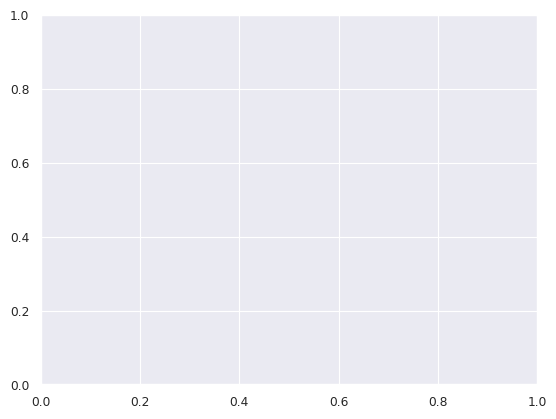

In [70]:
plt.plot(df_apple)

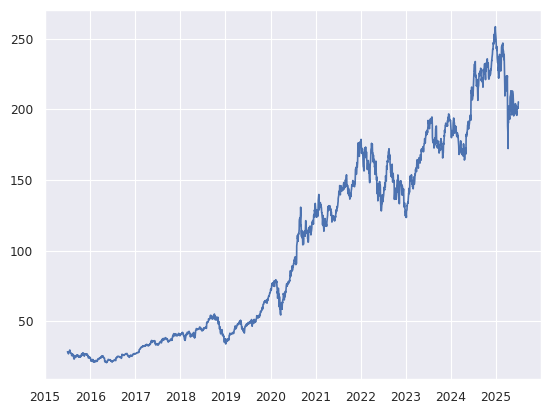

In [68]:
plt.plot(df_apple['ds'],df_apple['y'])

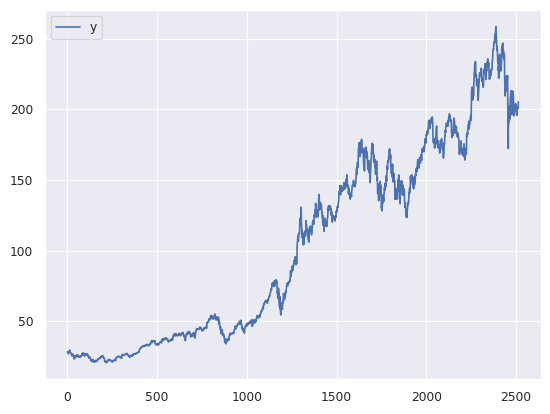

In [71]:
#import seaborn as sns

sns.lineplot(data=df_apple);

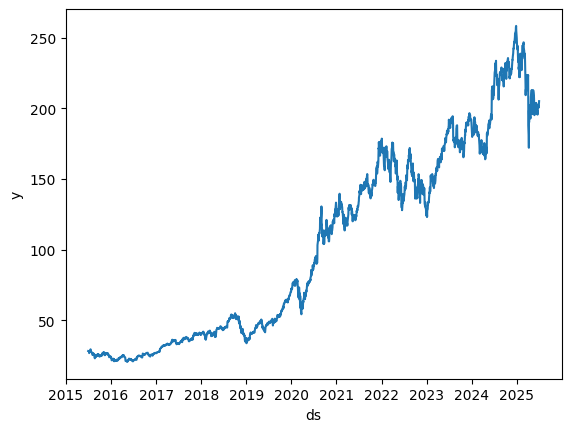

In [ ]:
sns.lineplot(data=df_apple, x='ds', y='y');

Además, podemos definir una figura vacía de Matplotlib para poder controlar el tamaño del gráfico de Seaborn:

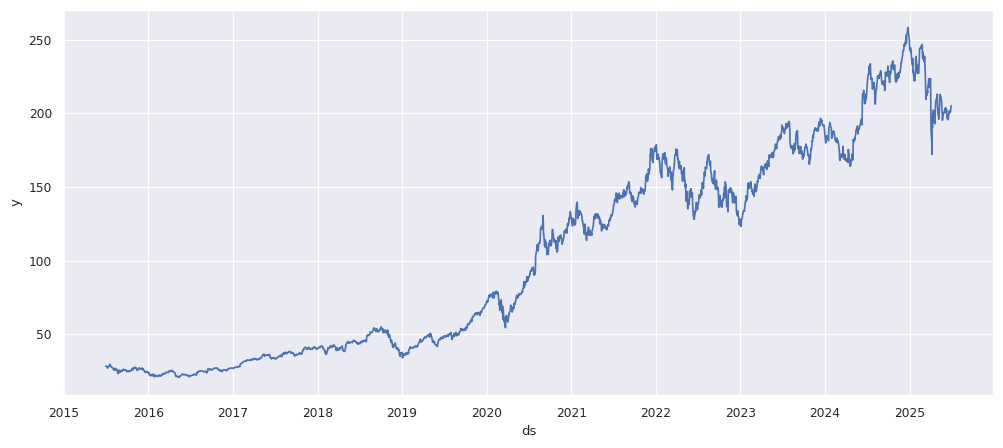

In [73]:
#import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_apple, x='ds', y='y', ax=ax);

Y podemos usar "lineplot" varias veces para superponer un gráfico sobre otro:

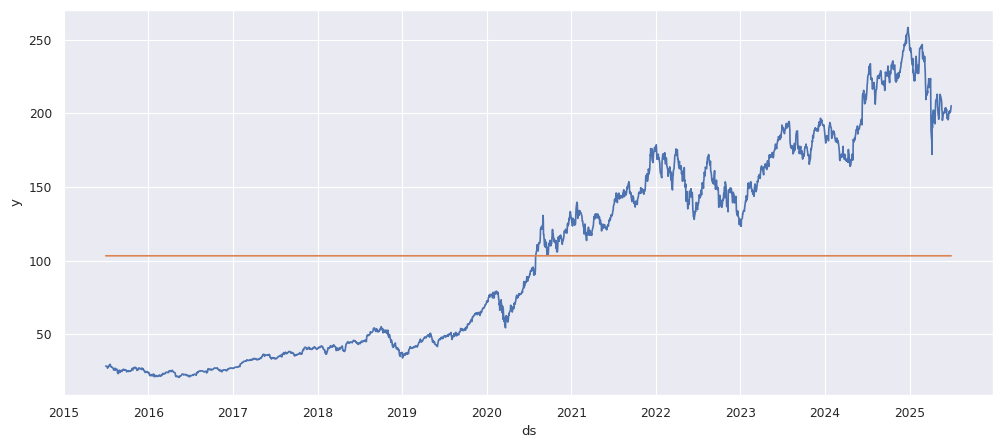

In [74]:
# Calcular el promedio histórico de la serie
df_apple['y_media'] = df_apple['y'].mean()

# Y dibujar las dos series
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_apple, x='ds', y='y', ax=ax)
sns.lineplot(data=df_apple, x='ds', y='y_media', ax=ax);

Los gráficos de histograma son muy usados en Ciencia de Datos, pues nos permiten ver la distribución de los datos.

Estos gráficos los podemos generar usando "histplot":

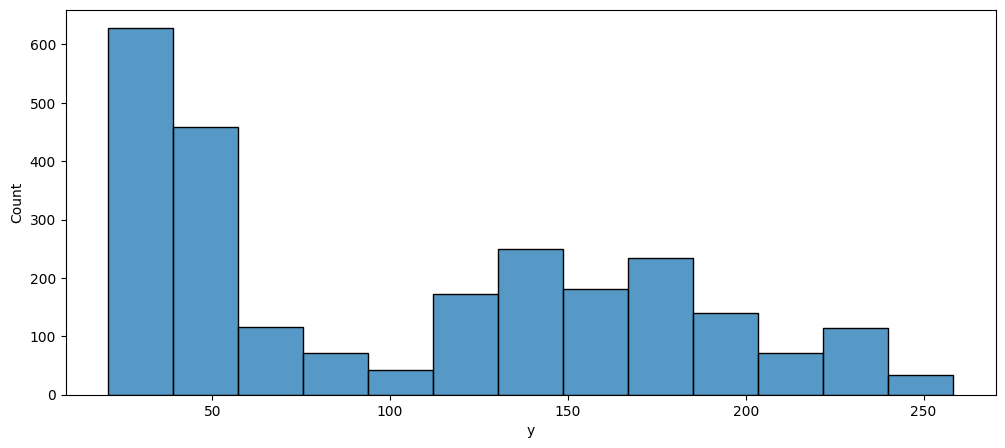

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df_apple, x='y', ax=ax);

Y podemos superponer la estimación de la distribución de probabilidad usando "kde=True":

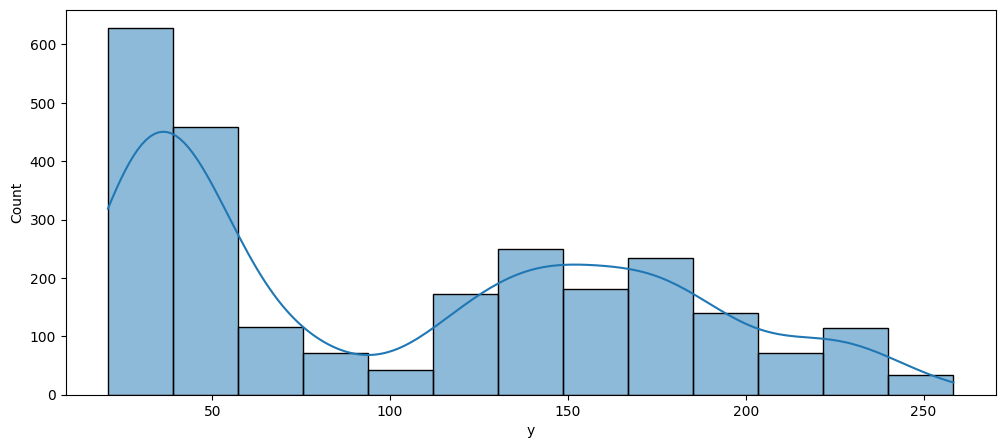

In [ ]:
# Gráfico de histograma con KDE
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df_apple, x='y', kde=True, ax=ax);

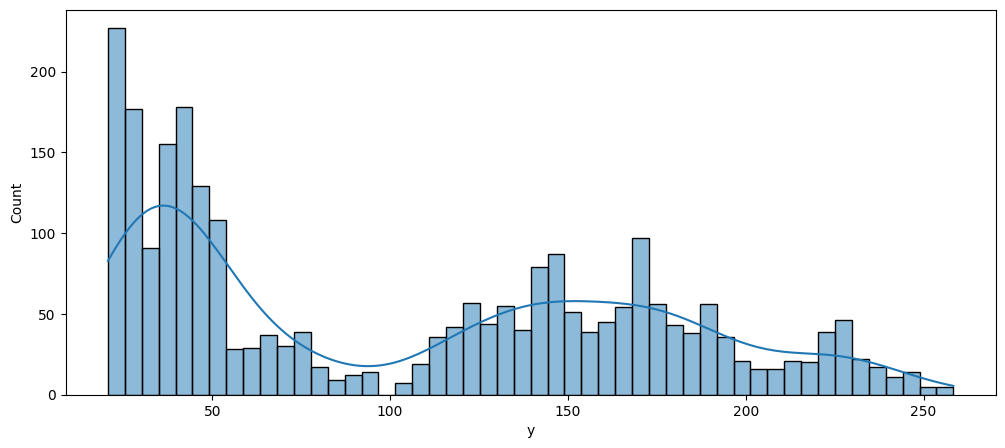

In [ ]:
# Controlar el número de bins del histograma
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=df_apple, x='y', bins=50, ax=ax, kde=True);

### Box plots:
Los gráficos de caja (o *box plots*) son otra herramienta muy útil en la exploración de datos. Además de permitirnos ver la distribución de los datos, facilitan detectar posibles "outliers".

Para generar estos gráficos usamos "boxplot":

### Scatter plos
...

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=df_mpg, x='mpg', y='horsepower', ax=ax);

## Laboratorio_1.2

1.   ... en proceso

  

